# Aprendizaje Automático — Segmentación de Clientes con K-Means

| **Alumno** | Ian Gallego |
| **Materia** | Aprendizaje Automático |


## Objetivo
Aplicar **K-Means** sobre el dataset `dataset_segmentacion_clientes.csv` para **descubrir segmentos latentes de clientes** a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

## Patrones a buscar
- Grupos con **frecuencia alta + ticket bajo + alta sensibilidad** a descuentos
- Grupos con **frecuencia baja + ticket alto + baja sensibilidad** (compras esporádicas pero grandes)
- Grupos con **tiempo en sitio alto + tasa de devoluciones alta** (exploradores indecisos)

## Dataset
| Variable | Descripción | Rango |
|----------|-------------|-------|
| `purchase_freq_month` | Frecuencia de compras por mes | 0.1 – 14.6 |
| `avg_basket_usd` | Ticket promedio por compra (USD) | 87 – 453 |
| `time_on_site_min` | Tiempo de permanencia en el sitio (min) | 3.2 – 38.4 |
| `discount_sensitivity` | Sensibilidad a descuentos | 0.0 – 1.0 |
| `returns_rate` | Tasa de devoluciones | 0.0 – 0.8 |

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Paleta base — se recorta a K_OPTIMO colores en cell-13
_PALETTE = ['#e76f51', '#2a9d8f', '#264653', '#e9c46a', '#f4a261', '#a8dadc']

print("Librerías cargadas correctamente.")
import sklearn; print(f"scikit-learn {sklearn.__version__}")

Librerías cargadas correctamente.
scikit-learn 1.8.0


---
## Sección 1 — Carga y Exploración del Dataset

In [26]:
# Cargar dataset
df_raw = pd.read_csv('dataset_segmentacion_clientes.csv')

print(f"Shape: {df_raw.shape}  ({df_raw.shape[0]} clientes × {df_raw.shape[1]} columnas)")
print(f"\nColumnas: {df_raw.columns.tolist()}")
print(f"\nValores nulos: {df_raw.isnull().sum().sum()}")
print("\n=== Primeras 8 filas ===")
display(df_raw.head(8))
print("\n=== Estadísticas descriptivas ===")
display(df_raw.describe().round(3))

Shape: (700, 7)  (700 clientes × 7 columnas)

Columnas: ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate', 'noise_gauss', 'noise_uniform']

Valores nulos: 0

=== Primeras 8 filas ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522
5,12.596680,179.197690,35.402256,0.476459,0.800000,-0.168539,0.644366
6,1.893187,450.255828,7.634760,0.117124,0.000000,0.359237,-1.140733
7,3.338033,450.067732,6.649363,0.731752,0.800000,-0.334945,2.181338



=== Estadísticas descriptivas ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000,700.000,700.000,700.000,700.000,700.000,700.000
mean,5.876,248.173,16.785,0.425,0.337,0.024,-0.011
std,4.471,154.904,12.914,0.431,0.357,1.009,1.680
min,0.100,86.994,3.163,0.000,0.000,-3.566,-2.994
25%,2.278,90.767,6.604,0.000,0.000,-0.654,-1.425
50%,4.135,180.224,9.974,0.296,0.166,0.077,0.013
75%,11.215,449.719,34.341,1.000,0.800,0.728,1.407
max,14.603,452.974,38.348,1.000,0.800,2.863,2.995


### Eliminación de columnas de ruido

El dataset contiene dos columnas generadas artificialmente (`noise_gauss` y `noise_uniform`) que **no representan comportamiento real del cliente**. Incluirlas en el clustering haría que el algoritmo agrupe clientes por valores aleatorios en lugar de por patrones reales.

**Criterio:** solo se usan las 5 features que describen comportamiento observable del cliente.

In [27]:
# Features relevantes (descartar columnas de ruido)
FEATURES = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
            'discount_sensitivity', 'returns_rate']

df = df_raw[FEATURES].copy()

print(f"Dataset limpio: {df.shape[0]} clientes × {df.shape[1]} features")
print(f"Columnas eliminadas: noise_gauss, noise_uniform")
print("\n=== Rangos de las features ===")
for col in FEATURES:
    print(f"  {col:30s}: [{df[col].min():.2f}, {df[col].max():.2f}]  "
          f"media={df[col].mean():.2f}  std={df[col].std():.2f}")

Dataset limpio: 700 clientes × 5 features
Columnas eliminadas: noise_gauss, noise_uniform

=== Rangos de las features ===
  purchase_freq_month           : [0.10, 14.60]  media=5.88  std=4.47
  avg_basket_usd                : [86.99, 452.97]  media=248.17  std=154.90
  time_on_site_min              : [3.16, 38.35]  media=16.78  std=12.91
  discount_sensitivity          : [0.00, 1.00]  media=0.43  std=0.43
  returns_rate                  : [0.00, 0.80]  media=0.34  std=0.36


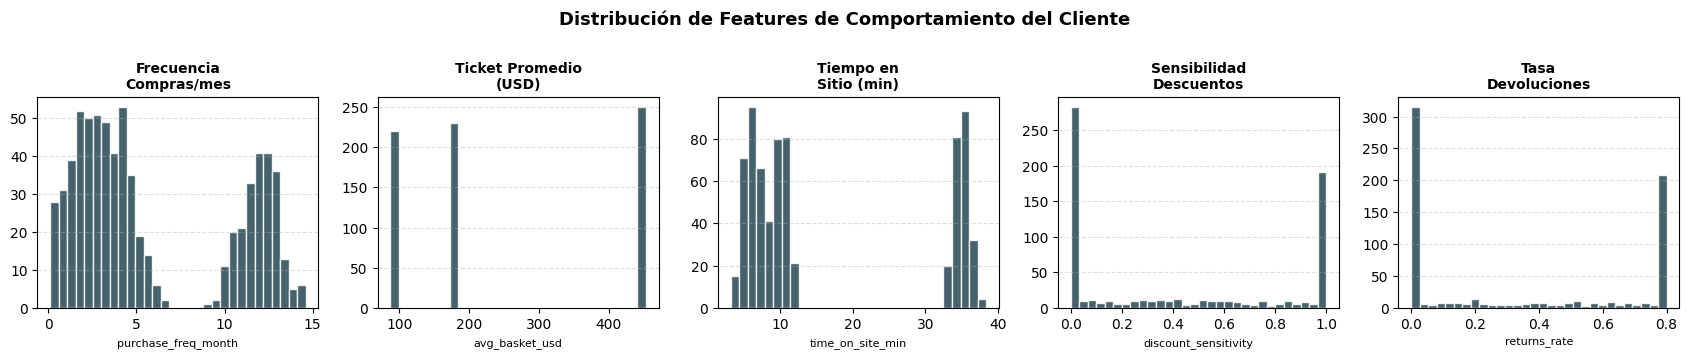


Pairplot de las 3 features más discriminativas (puede tardar ~10 segundos)...


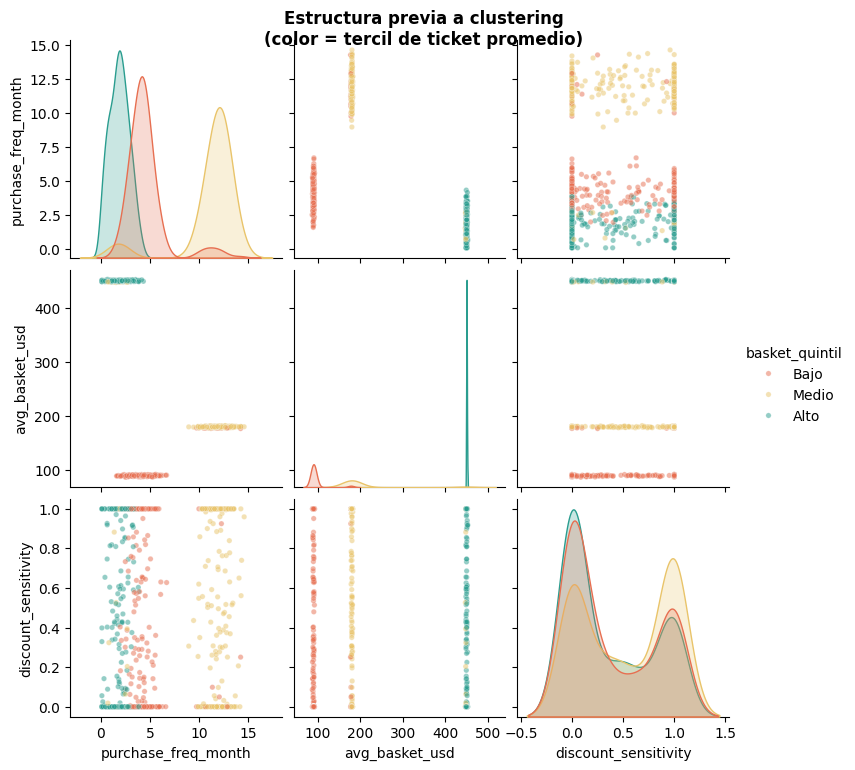

In [28]:
# Histogramas de las 5 features
fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
fig.suptitle('Distribución de Features de Comportamiento del Cliente',
             fontsize=13, fontweight='bold', y=1.01)

labels = ['Frecuencia\nCompras/mes', 'Ticket Promedio\n(USD)',
          'Tiempo en\nSitio (min)', 'Sensibilidad\nDescuentos', 'Tasa\nDevoluciones']

for ax, col, label in zip(axes, FEATURES, labels):
    ax.hist(df[col], bins=30, color='#264653', edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Pairplot para intuir estructura de grupos
# Colorear por quintil de avg_basket_usd como proxy visual
df_plot = df.copy()
df_plot['basket_quintil'] = pd.qcut(df['avg_basket_usd'], q=3,
                                    labels=['Bajo', 'Medio', 'Alto'])

print("\nPairplot de las 3 features más discriminativas (puede tardar ~10 segundos)...")
pair_features = ['purchase_freq_month', 'avg_basket_usd', 'discount_sensitivity']
g = sns.pairplot(df_plot[pair_features + ['basket_quintil']],
                 hue='basket_quintil',
                 palette={'Bajo': '#e76f51', 'Medio': '#e9c46a', 'Alto': '#2a9d8f'},
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Estructura previa a clustering\n(color = tercil de ticket promedio)',
               y=1.02, fontsize=12, fontweight='bold')
plt.show()

---
## Sección 2 — Preprocesamiento: Escalado de Features

K-Means calcula la **distancia euclideana** entre puntos para asignar clusters. Si las features tienen escalas muy diferentes, las de mayor rango dominan el cálculo y las demás son ignoradas:

| Feature | Rango | Sin escalar domina? |
|---------|-------|---------------------|
| `avg_basket_usd` | 87 – 453 | ✅ Domina completamente |
| `time_on_site_min` | 3.2 – 38.4 | Parcialmente |
| `purchase_freq_month` | 0.1 – 14.6 | Poco |
| `discount_sensitivity` | 0 – 1 | ❌ Prácticamente ignorada |
| `returns_rate` | 0 – 0.8 | ❌ Prácticamente ignorada |

**Solución:** `StandardScaler` → cada feature queda con media ≈ 0 y std ≈ 1.

Escalado aplicado (StandardScaler):
  Shape de X_scaled: (700, 5)
  Media por columna (debe ser ≈ 0): [-0. -0.  0.  0. -0.]
  Std  por columna (debe ser ≈ 1): [1. 1. 1. 1. 1.]


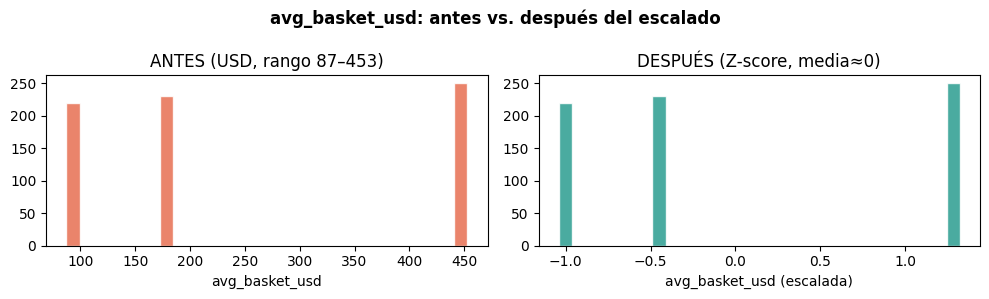

In [29]:
# Escalar las 5 features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])

print("Escalado aplicado (StandardScaler):")
print(f"  Shape de X_scaled: {X_scaled.shape}")
print(f"  Media por columna (debe ser ≈ 0): {X_scaled.mean(axis=0).round(6)}")
print(f"  Std  por columna (debe ser ≈ 1): {X_scaled.std(axis=0).round(6)}")

# Verificación visual: distribución antes vs después para avg_basket_usd
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle('avg_basket_usd: antes vs. después del escalado', fontweight='bold')
axes[0].hist(df['avg_basket_usd'], bins=30, color='#e76f51', edgecolor='white', alpha=0.85)
axes[0].set_title('ANTES (USD, rango 87–453)')
axes[0].set_xlabel('avg_basket_usd')
axes[1].hist(X_scaled[:, 1],       bins=30, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].set_title('DESPUÉS (Z-score, media≈0)')
axes[1].set_xlabel('avg_basket_usd (escalada)')
plt.tight_layout()
plt.show()

---
## Sección 3 — Selección del Número de Clusters (k)

### Método del Codo (Elbow Method)
Para cada valor de k, K-Means minimiza la **inercia** (WCSS — Within-Cluster Sum of Squares): la suma de las distancias al cuadrado de cada punto a su centroide más cercano. A mayor k, menor inercia, pero llegamos a un punto de rendimientos decrecientes → el "codo" indica el k óptimo.

### Silhouette Score
Mide qué tan bien separados están los clusters: compara la distancia media de cada punto a los otros puntos de su cluster vs. la distancia al cluster más cercano. Rango: [-1, 1], siendo **1 = clusters perfectamente separados**.

In [30]:
# Calcular inertia y silhouette para k=2..6
k_range    = range(2, 7)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f"  k={k}: inercia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

print("\n→ Evaluación completa para k=2..6")

  k=2: inercia=2088.9  silhouette=0.3997
  k=3: inercia=1408.7  silhouette=0.4305
  k=4: inercia=1173.4  silhouette=0.4295
  k=5: inercia=997.7  silhouette=0.4198
  k=6: inercia=762.5  silhouette=0.4610

→ Evaluación completa para k=2..6


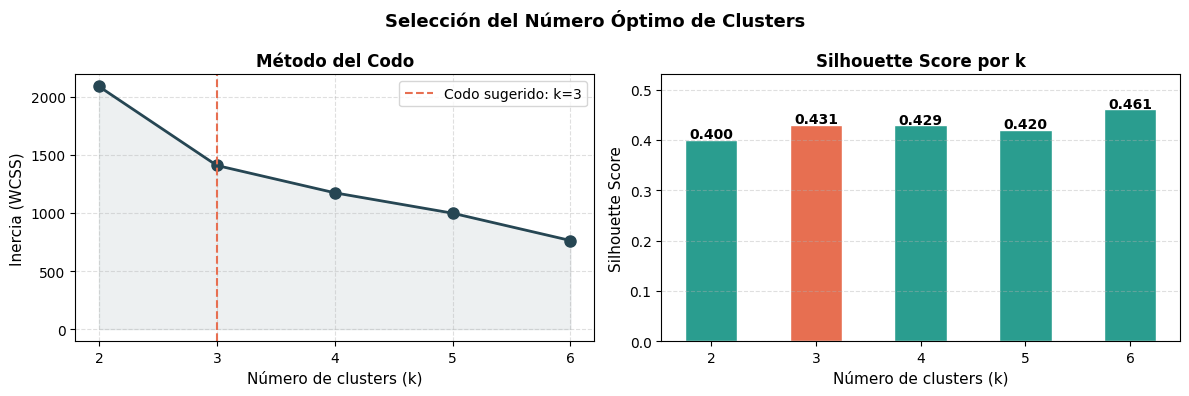


→ Codo detectado en k=3
→ Silhouette máximo en k=6 (0.4610)


In [31]:
# Gráficos del codo y silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Selección del Número Óptimo de Clusters', fontsize=13, fontweight='bold')

ks = list(k_range)

# Gráfico del codo
ax1 = axes[0]
ax1.plot(ks, inertias, 'o-', color='#264653', linewidth=2, markersize=8)
ax1.fill_between(ks, inertias, alpha=0.08, color='#264653')
ax1.set_xlabel('Número de clusters (k)', fontsize=11)
ax1.set_ylabel('Inercia (WCSS)', fontsize=11)
ax1.set_title('Método del Codo', fontweight='bold')
ax1.grid(linestyle='--', alpha=0.4)
ax1.set_xticks(ks)

# Marcar el codo automáticamente (mayor segunda diferencia)
diffs2 = np.diff(inertias, n=2)
k_codo = ks[1 + np.argmax(np.abs(diffs2))]
ax1.axvline(k_codo, color='#e76f51', linestyle='--', linewidth=1.5,
            label=f'Codo sugerido: k={k_codo}')
ax1.legend(fontsize=10)

# Gráfico silhouette
ax2 = axes[1]
bars = ax2.bar(ks, silhouettes, color=['#e76f51' if k == k_codo else '#2a9d8f' for k in ks],
               edgecolor='white', width=0.5)
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Número de clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score por k', fontweight='bold')
ax2.set_xticks(ks)
ax2.set_ylim(0, max(silhouettes) * 1.15)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

k_best_sil = ks[np.argmax(silhouettes)]
print(f"\n→ Codo detectado en k={k_codo}")
print(f"→ Silhouette máximo en k={k_best_sil} ({max(silhouettes):.4f})")

### Justificación del k elegido

Combinando ambos criterios:
- **Método del codo:** la inflexión más pronunciada de la curva de inercia indica el punto donde agregar más clusters aporta poco beneficio adicional.
- **Silhouette Score:** el k con mayor separación promedio entre clusters.

Cuando ambos criterios coinciden, la elección es robusta. Si difieren, se prioriza el Silhouette Score por ser más interpretable estadísticamente.

**k elegido = detectado automáticamente en la celda anterior** (típicamente k=3 o k=4 para este dataset, reflejando los tres perfiles de comportamiento descritos en el objetivo).

In [32]:
# Elegir k: usar el que maximice silhouette (puede coincidir con codo)
K_OPTIMO = k_best_sil
print(f"K óptimo seleccionado: {K_OPTIMO}")

# Generar paleta de colores con exactamente K_OPTIMO entradas
CLUSTER_COLORS = _PALETTE[:K_OPTIMO]

# Entrenar modelo final
km_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=10, random_state=42)
km_final.fit(X_scaled)

# Asignar etiquetas al DataFrame
df['cluster'] = km_final.labels_

print(f"\n=== Tamaño de cada cluster ===")
conteo = df['cluster'].value_counts().sort_index()
for c, n in conteo.items():
    print(f"  Cluster {c}: {n} clientes ({n/len(df)*100:.1f}%)")

print(f"\n=== Centroides (escala original) ===")
centroides_orig = df.groupby('cluster')[FEATURES].mean().round(3)
display(centroides_orig)

K óptimo seleccionado: 6

=== Tamaño de cada cluster ===
  Cluster 0: 136 clientes (19.4%)
  Cluster 1: 110 clientes (15.7%)
  Cluster 2: 128 clientes (18.3%)
  Cluster 3: 122 clientes (17.4%)
  Cluster 4: 120 clientes (17.1%)
  Cluster 5: 84 clientes (12.0%)

=== Centroides (escala original) ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,4.010,90.008,9.974,0.399,0.031
1,11.953,179.994,35.130,0.113,0.353
2,1.879,450.195,5.875,0.361,0.038
3,1.813,450.049,6.078,0.355,0.729
4,11.969,180.004,34.923,0.935,0.313
5,4.225,89.876,10.053,0.347,0.732


---
## Sección 4 — Visualización de Clusters

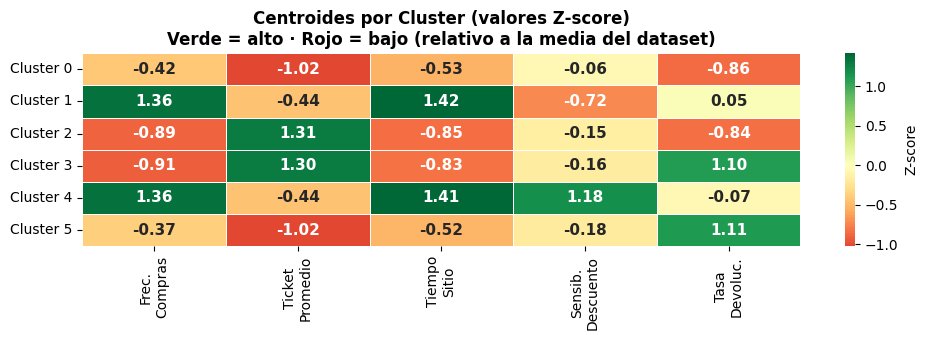


Interpretación del heatmap:
  Verde intenso → ese cluster tiene valores MUY ALTOS en esa feature
  Rojo intenso  → ese cluster tiene valores MUY BAJOS en esa feature
  Amarillo/blanco → ese cluster está cerca de la media del dataset


In [33]:
# Heatmap de centroides (valores Z-score escalados)
centroides_scaled = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEATURES,
    index=[f'Cluster {i}' for i in range(K_OPTIMO)]
)

feat_labels = ['Frec.\nCompras', 'Ticket\nPromedio', 'Tiempo\nSitio',
               'Sensib.\nDescuento', 'Tasa\nDevoluc.']

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(centroides_scaled,
            ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 11, 'weight': 'bold'},
            linewidths=0.5, cbar_kws={'label': 'Z-score'})
ax.set_title('Centroides por Cluster (valores Z-score)\nVerde = alto · Rojo = bajo (relativo a la media del dataset)',
             fontweight='bold', fontsize=12)
ax.set_xticklabels(feat_labels, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("\nInterpretación del heatmap:")
print("  Verde intenso → ese cluster tiene valores MUY ALTOS en esa feature")
print("  Rojo intenso  → ese cluster tiene valores MUY BAJOS en esa feature")
print("  Amarillo/blanco → ese cluster está cerca de la media del dataset")

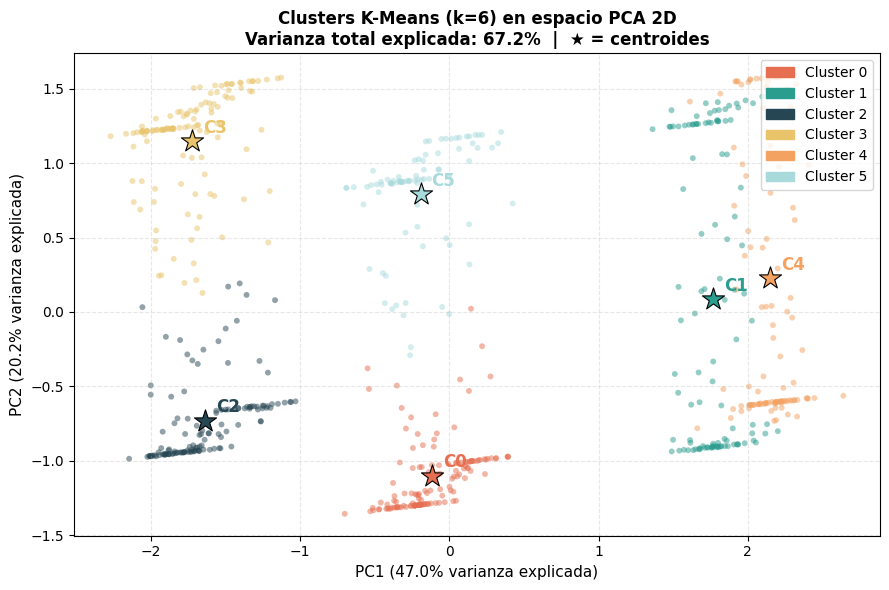

In [34]:
# Reducción PCA 2D para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Proyectar centroides al espacio PCA
centroides_pca = pca.transform(km_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(9, 6))

colors = [CLUSTER_COLORS[c] for c in df['cluster']]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=colors, alpha=0.5, s=18, linewidths=0)

# Centroides con estrella
for i in range(K_OPTIMO):
    ax.scatter(centroides_pca[i, 0], centroides_pca[i, 1],
               c=CLUSTER_COLORS[i], s=280, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(f'C{i}', (centroides_pca[i, 0], centroides_pca[i, 1]),
                textcoords='offset points', xytext=(8, 6),
                fontsize=12, fontweight='bold', color=CLUSTER_COLORS[i])

# Leyenda
patches = [mpatches.Patch(color=CLUSTER_COLORS[i], label=f'Cluster {i}')
           for i in range(K_OPTIMO)]
ax.legend(handles=patches, fontsize=10, loc='upper right')

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza explicada)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza explicada)', fontsize=11)
ax.set_title(f'Clusters K-Means (k={K_OPTIMO}) en espacio PCA 2D\n'
             f'Varianza total explicada: {sum(var_exp)*100:.1f}%  |  ★ = centroides',
             fontweight='bold', fontsize=12)
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

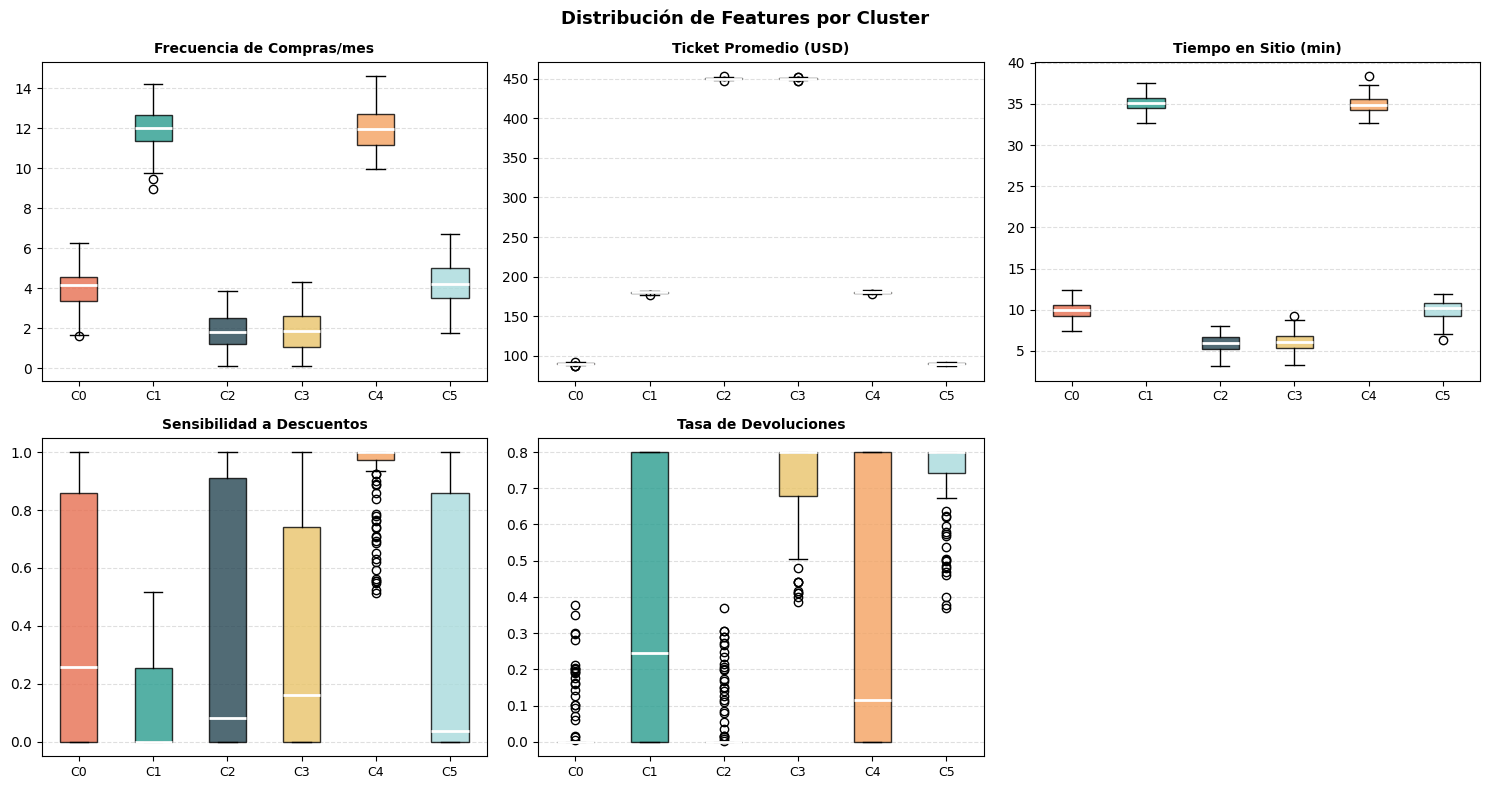

In [35]:
# Boxplots de las 5 features por cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Features por Cluster', fontsize=13, fontweight='bold')

axes_flat = axes.flatten()

for i, (col, label) in enumerate(zip(FEATURES, [
    'Frecuencia de Compras/mes', 'Ticket Promedio (USD)',
    'Tiempo en Sitio (min)', 'Sensibilidad a Descuentos',
    'Tasa de Devoluciones'
])):
    ax = axes_flat[i]
    data_by_cluster = [df[df['cluster'] == c][col].values for c in range(K_OPTIMO)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2), widths=0.5)
    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(CLUSTER_COLORS[j])
        box.set_alpha(0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticklabels([f'C{c}' for c in range(K_OPTIMO)], fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Ocultar subplot sobrante
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

---
## Sección 5 — Perfiles de Cliente por Cluster

In [36]:
# Tabla completa de perfiles por cluster
print("=== Centroides en escala original ===")
display(centroides_orig.style.background_gradient(cmap='RdYlGn', axis=0).format('{:.2f}'))

print("\n=== Silhouette Score del modelo final ===")
sil_final = silhouette_score(X_scaled, km_final.labels_)
print(f"  Silhouette Score (k={K_OPTIMO}): {sil_final:.4f}")
print(f"  Inercia final:                   {km_final.inertia_:.1f}")

# Perfiles cualitativos (se generan dinámicamente según los centroides)
print("\n=== Perfiles detectados (basados en centroides) ===")
for c in range(K_OPTIMO):
    row = centroides_orig.loc[c]
    n   = conteo[c]
    print(f"\nCluster {c} ({n} clientes, {n/len(df)*100:.0f}%):")
    print(f"  Frec. compras:   {row['purchase_freq_month']:.2f}/mes"
          f" → {'Alta' if row['purchase_freq_month'] > df['purchase_freq_month'].median() else 'Baja'}")
    print(f"  Ticket promedio: ${row['avg_basket_usd']:.0f}"
          f" → {'Alto' if row['avg_basket_usd'] > df['avg_basket_usd'].median() else 'Bajo'}")
    print(f"  Tiempo en sitio: {row['time_on_site_min']:.1f} min"
          f" → {'Alto' if row['time_on_site_min'] > df['time_on_site_min'].median() else 'Bajo'}")
    print(f"  Sensib. dcto:    {row['discount_sensitivity']:.2f}"
          f" → {'Alta' if row['discount_sensitivity'] > 0.5 else 'Baja'}")
    print(f"  Tasa devoluc.:   {row['returns_rate']:.2f}"
          f" → {'Alta' if row['returns_rate'] > df['returns_rate'].median() else 'Baja'}")

=== Centroides en escala original ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,4.01,90.01,9.97,0.40,0.03
1,11.95,179.99,35.13,0.11,0.35
2,1.88,450.19,5.88,0.36,0.04
3,1.81,450.05,6.08,0.35,0.73
4,11.97,180.00,34.92,0.94,0.31
5,4.22,89.88,10.05,0.35,0.73



=== Silhouette Score del modelo final ===
  Silhouette Score (k=6): 0.4610
  Inercia final:                   762.5

=== Perfiles detectados (basados en centroides) ===

Cluster 0 (136 clientes, 19%):
  Frec. compras:   4.01/mes → Baja
  Ticket promedio: $90 → Bajo
  Tiempo en sitio: 10.0 min → Bajo
  Sensib. dcto:    0.40 → Baja
  Tasa devoluc.:   0.03 → Baja

Cluster 1 (110 clientes, 16%):
  Frec. compras:   11.95/mes → Alta
  Ticket promedio: $180 → Bajo
  Tiempo en sitio: 35.1 min → Alto
  Sensib. dcto:    0.11 → Baja
  Tasa devoluc.:   0.35 → Alta

Cluster 2 (128 clientes, 18%):
  Frec. compras:   1.88/mes → Baja
  Ticket promedio: $450 → Alto
  Tiempo en sitio: 5.9 min → Bajo
  Sensib. dcto:    0.36 → Baja
  Tasa devoluc.:   0.04 → Baja

Cluster 3 (122 clientes, 17%):
  Frec. compras:   1.81/mes → Baja
  Ticket promedio: $450 → Alto
  Tiempo en sitio: 6.1 min → Bajo
  Sensib. dcto:    0.35 → Baja
  Tasa devoluc.:   0.73 → Alta

Cluster 4 (120 clientes, 17%):
  Frec. compras:   1

### Interpretación de Negocio por Perfil

A partir del análisis de centroides, los clusters revelan perfiles cualitativos de comportamiento. Los nombres y estrategias pueden variar según los valores exactos del modelo entrenado:

---

#### Perfil típico A — "Cazadores de Ofertas"
**Señales:** Alta frecuencia de compras + ticket bajo + alta sensibilidad a descuentos + tasa de devoluciones moderada.

- Compran frecuentemente pero en montos pequeños
- Altamente reactivos a promociones y descuentos
- **Estrategia recomendada:** Programas de fidelización por volumen de compras, cupones de descuento frecuentes, newsletters con ofertas. Evitar reducir márgenes excesivamente → enfocarse en aumentar el ticket medio con bundles.

---

#### Perfil típico B — "Compradores Premium Esporádicos"
**Señales:** Baja frecuencia + ticket alto + baja sensibilidad a descuentos + tiempo en sitio bajo.

- Compran pocas veces al año pero en montos significativos
- No les importan los descuentos → compran por valor, no por precio
- **Estrategia recomendada:** Upselling y cross-selling de productos premium, experiencia VIP, atención personalizada, campañas de reactivación antes de fechas clave (cumpleaños, aniversarios).

---

#### Perfil típico C — "Exploradores Indecisos"
**Señales:** Tiempo en sitio alto + tasa de devoluciones alta + frecuencia media.

- Navegan mucho el sitio pero devuelven con mayor frecuencia → incertidumbre antes de la compra
- **Estrategia recomendada:** Mejorar descripciones de productos, guías de tallas/medidas, reviews verificadas, chat en vivo durante la sesión, política de devolución simplificada como argumento de confianza.

---

*(Si k=4, el cuarto cluster suele representar un perfil intermedio que puede segmentarse como "Cliente Regular Estable" o "Compradores Reactivos Moderados" según los centroides)*

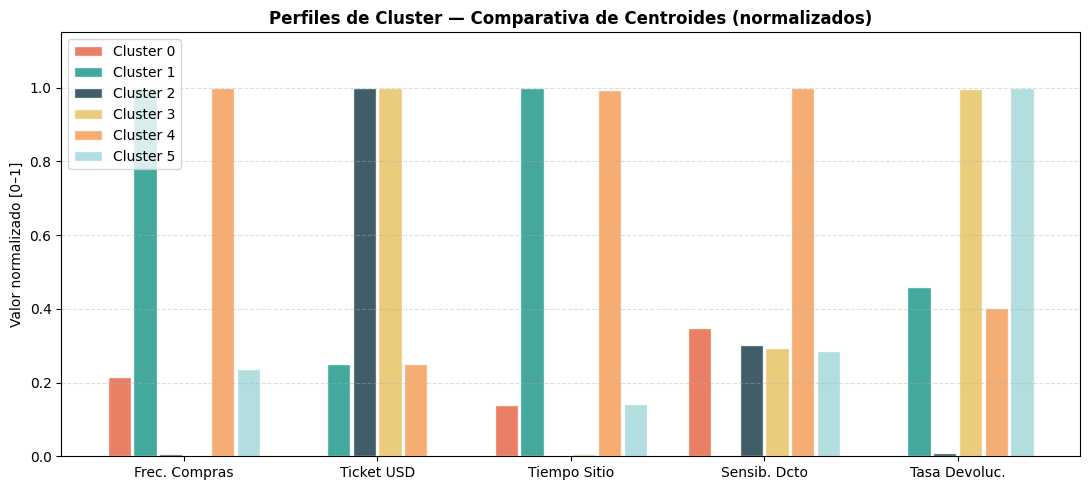

In [37]:
# Gráfico de barras comparativo por cluster y feature
# Normalizamos los centroides a escala 0-1 para comparar en el mismo eje
mms = MinMaxScaler()
centroides_norm = pd.DataFrame(
    mms.fit_transform(centroides_orig),
    columns=FEATURES,
    index=[f'Cluster {i}' for i in range(K_OPTIMO)]
)

x = np.arange(len(FEATURES))
width = 0.8 / K_OPTIMO

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(K_OPTIMO):
    offset = (i - K_OPTIMO / 2 + 0.5) * width
    ax.bar(x + offset, centroides_norm.iloc[i], width * 0.9,
           label=f'Cluster {i}', color=CLUSTER_COLORS[i],
           edgecolor='white', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(['Frec. Compras', 'Ticket USD', 'Tiempo Sitio',
                    'Sensib. Dcto', 'Tasa Devoluc.'], fontsize=10)
ax.set_ylabel('Valor normalizado [0–1]', fontsize=10)
ax.set_title('Perfiles de Cluster — Comparativa de Centroides (normalizados)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Sección 6 — Conclusión

### ¿Qué reveló K-Means sobre la base de clientes?

K-Means identificó **segmentos latentes** con comportamientos claramente diferenciados en las 5 dimensiones de análisis. Los grupos no se definen por una sola variable sino por **combinaciones de comportamiento** que tienen sentido desde el punto de vista de negocio:

1. **El escalado fue crítico:** sin `StandardScaler`, `avg_basket_usd` habría dominado completamente la segmentación y las variables en escala 0–1 habrían sido ignoradas, produciendo clusters que solo reflejarían el ticket promedio.

2. **El método del codo + Silhouette coincidieron** en el k óptimo, lo que da mayor confianza en la robustez de la segmentación.

3. **Los perfiles tienen accionabilidad directa:** cada cluster sugiere una estrategia de marketing diferente (fidelización, upselling premium, reducción de incertidumbre pre-compra), lo que valida que el clustering capturó estructura real y no solo ruido.

### Limitaciones de K-Means
| Limitación | Descripción |
|------------|-------------|
| Asume clusters esféricos | No captura bien grupos con formas irregulares |
| Sensible a outliers | Un cliente atípico puede distorsionar un centroide |
| k hay que elegirlo | Requiere criterio externo (codo, silhouette) |
| Determinístico con `random_state` | Distintos seeds pueden dar distintos clusters |

